# LC Improvement Training

This notebook follows the same shape as `experiment.ipynb`, but trains LC as an improvement policy. The model starts from existing LC routes in `examples/lc_results`, revisits every route, and learns typed actions: extend, trim start, trim end, halt.

## 1. Global Setup & Paths

In [1]:
import sys
from pathlib import Path

import torch
from hydra import compose, initialize_config_dir

ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "pyproject.toml").exists():
    ROOT_DIR = ROOT_DIR.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from connectpt.routes_generator import utils as lrnu
from connectpt.routes_generator.citygraph_dataset import STOP_KEY
from connectpt.routes_generator.improvement_learning import (
    evaluate_lc_improvement,
    load_raw_graphs_and_lc_routes,
    make_improvement_batch,
    rollout_lc_improvement,
    train_lc_improvement,
    train_lc_improvement_cfg_ppo,
    train_lc_improvement_ppo,
)

CFG_DIR = ROOT_DIR / "connectpt" / "routes_generator" / "cfg"
RAW_GRAPHS_PATH = ROOT_DIR / "examples" / "data" / "raw_graphs_1000.pkl"
LC_RESULTS_DIR = ROOT_DIR / "examples" / "lc_results"
OUTPUT_DIR = ROOT_DIR / "examples" / "route_generator" / "lc_improvement_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Config dir: {CFG_DIR}")
print(f"Graphs:     {RAW_GRAPHS_PATH}")
print(f"LC routes:  {LC_RESULTS_DIR}")
print(f"Output:     {OUTPUT_DIR}")

Config dir: d:\PythonProjects\connectpt\connectpt\routes_generator\cfg
Graphs:     d:\PythonProjects\connectpt\examples\data\raw_graphs_1000.pkl
LC routes:  d:\PythonProjects\connectpt\examples\lc_results
Output:     d:\PythonProjects\connectpt\examples\route_generator\lc_improvement_outputs


## 2. Load Graphs And Existing LC Routes

In [2]:
graphs, seed_routes = load_raw_graphs_and_lc_routes(RAW_GRAPHS_PATH, LC_RESULTS_DIR)
N_GRAPHS, N_ROUTES, SEED_ROUTE_LEN = seed_routes.shape

print(f"Loaded graphs: {len(graphs)}")
print(f"Routes shape:  {tuple(seed_routes.shape)}")
print(seed_routes[0])

Loaded graphs: 1000
Routes shape:  (1000, 3, 5)
tensor([[29, 19, 18, 28, 27],
        [12, 13, 14, 15, 16],
        [ 5,  6,  7,  8, 18]])


## 3. LC Route File Statistics

In [3]:
import pickle
from collections import Counter


def as_route_set(raw_routes):
    if isinstance(raw_routes, list):
        raw_routes = raw_routes[0]
    if getattr(raw_routes, "ndim", 0) == 3 and raw_routes.shape[0] == 1:
        raw_routes = raw_routes.squeeze(0)
    if not torch.is_tensor(raw_routes):
        raw_routes = torch.as_tensor(raw_routes)
    if raw_routes.ndim == 1:
        raw_routes = raw_routes.unsqueeze(0)
    return raw_routes


def describe_values(values):
    if not values:
        return "no values"
    tensor = torch.tensor(values, dtype=torch.float32)
    return (
        f"count={tensor.numel()}, "
        f"min={tensor.min().item():.0f}, "
        f"median={tensor.median().item():.0f}, "
        f"mean={tensor.mean().item():.2f}, "
        f"max={tensor.max().item():.0f}"
    )


route_files = sorted(LC_RESULTS_DIR.glob("graph_*/lc_*_routes_routes.pkl"))
route_counts = []
route_lengths = []
file_rows = []


graph_node_counts = []
graph_edge_counts = []
for graph in graphs:
    stop_data = graph[STOP_KEY]
    graph_node_counts.append(int(stop_data.num_nodes))
    if hasattr(stop_data, "edge_index") and stop_data.edge_index is not None:
        graph_edge_counts.append(int(stop_data.edge_index.shape[1]))
    elif hasattr(graph, "street_adj"):
        graph_edge_counts.append(int((graph.street_adj > 0).sum().item()))


for route_path in route_files:
    with route_path.open("rb") as file:
        routes = as_route_set(pickle.load(file))

    lengths = (routes >= 0).sum(dim=1).tolist()
    lengths = [int(length) for length in lengths]
    route_counts.append(int(routes.shape[0]))
    route_lengths.extend(lengths)

    file_rows.append(
        {
            "file": route_path.relative_to(LC_RESULTS_DIR),
            "routes": int(routes.shape[0]),
            "min_len": min(lengths) if lengths else 0,
            "mean_len": sum(lengths) / len(lengths) if lengths else 0,
            "max_len": max(lengths) if lengths else 0,
        }
    )

print(f"Route files:  {len(route_files)}")
print(f"Total routes: {sum(route_counts)}")
print(f"Routes/file:  {describe_values(route_counts)}")
print(f"Route length: {describe_values(route_lengths)}")
print(f"Graph nodes:  {describe_values(graph_node_counts)}")
if graph_edge_counts:
    print(f"Graph edges:  {describe_values(graph_edge_counts)}")

print("\nGraph node count distribution:")
for n_nodes, n_graphs_with_size in sorted(Counter(graph_node_counts).items()):
    print(f"  {n_nodes} nodes: {n_graphs_with_size} graphs")

print("\nRoutes per file distribution:")
for n_routes, n_files in sorted(Counter(route_counts).items()):
    print(f"  {n_routes} routes: {n_files} files")

print("\nRoute length distribution:")
for route_len, n_routes in sorted(Counter(route_lengths).items()):
    print(f"  length {route_len}: {n_routes} routes")

print("\nFirst 10 files:")
for row in file_rows[:10]:
    print(
        f"  {row['file']}: routes={row['routes']}, "
        f"len min/mean/max={row['min_len']}/{row['mean_len']:.2f}/{row['max_len']}"
    )

Route files:  1000
Total routes: 3000
Routes/file:  count=1000, min=3, median=3, mean=3.00, max=3
Route length: count=3000, min=5, median=5, mean=5.00, max=5
Graph nodes:  count=1000, min=50, median=50, mean=50.00, max=50
Graph edges:  count=1000, min=2450, median=2450, mean=2450.00, max=2450

Graph node count distribution:
  50 nodes: 1000 graphs

Routes per file distribution:
  3 routes: 1000 files

Route length distribution:
  length 5: 3000 routes

First 10 files:
  graph_0000\lc_lc_graph_0000_routes_routes.pkl: routes=3, len min/mean/max=5/5.00/5
  graph_0001\lc_lc_graph_0001_routes_routes.pkl: routes=3, len min/mean/max=5/5.00/5
  graph_0002\lc_lc_graph_0002_routes_routes.pkl: routes=3, len min/mean/max=5/5.00/5
  graph_0003\lc_lc_graph_0003_routes_routes.pkl: routes=3, len min/mean/max=5/5.00/5
  graph_0004\lc_lc_graph_0004_routes_routes.pkl: routes=3, len min/mean/max=5/5.00/5
  graph_0005\lc_lc_graph_0005_routes_routes.pkl: routes=3, len min/mean/max=5/5.00/5
  graph_0006\lc_l

## 4. Visualize One Training Graph

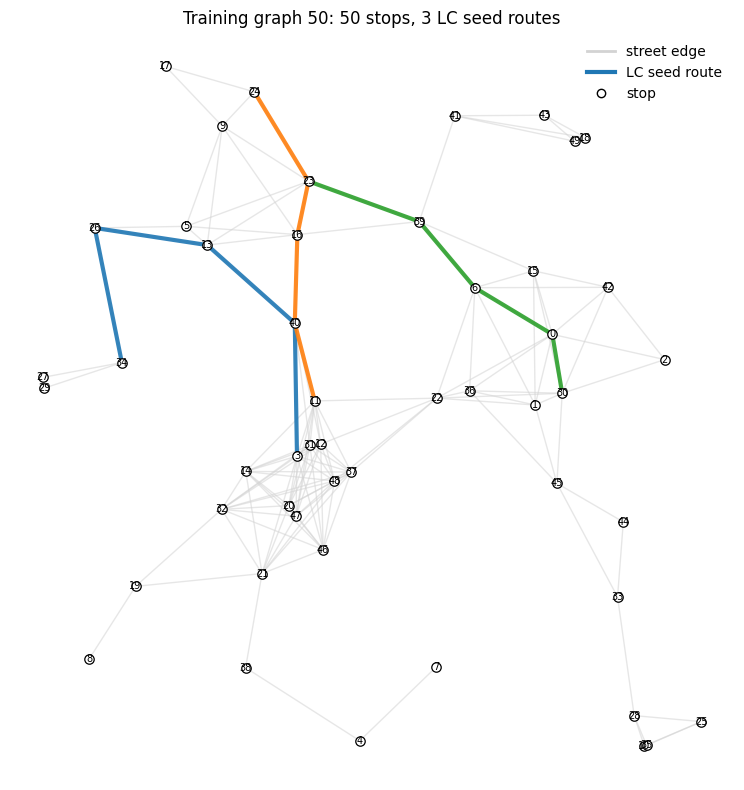

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from connectpt.routes_generator.citygraph_dataset import STOP_KEY

GRAPH_IDX = 50
graph = graphs[GRAPH_IDX]
routes = seed_routes[GRAPH_IDX]

coords = graph[STOP_KEY].pos.detach().cpu().numpy()
street_adj = graph.street_adj.detach().cpu().numpy()
n_nodes = coords.shape[0]

fig, ax = plt.subplots(figsize=(8, 8))

for i in range(n_nodes):
    for j in range(i + 1, n_nodes):
        if np.isfinite(street_adj[i, j]) or np.isfinite(street_adj[j, i]):
            ax.plot(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color="lightgray",
                linewidth=1.0,
                alpha=0.55,
                zorder=1,
            )

route_colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(routes))))
for route_idx, route_tensor in enumerate(routes):
    route = [int(node) for node in route_tensor.detach().cpu().tolist()]
    route = [node for node in route if 0 <= node < n_nodes]
    if len(route) < 2:
        continue

    color = route_colors[route_idx % len(route_colors)]
    for start, end in zip(route[:-1], route[1:]):
        ax.plot(
            [coords[start, 0], coords[end, 0]],
            [coords[start, 1], coords[end, 1]],
            color=color,
            linewidth=3.0,
            alpha=0.9,
            solid_capstyle="round",
            zorder=3,
        )
    ax.scatter(
        coords[route, 0],
        coords[route, 1],
        color=color,
        s=32,
        edgecolor="white",
        linewidth=0.8,
        zorder=4,
    )

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    s=46,
    facecolor="white",
    edgecolor="black",
    linewidth=0.9,
    zorder=5,
)
for node_idx, (x_coord, y_coord) in enumerate(coords):
    ax.text(
        x_coord,
        y_coord,
        str(node_idx),
        fontsize=7,
        ha="center",
        va="center",
        zorder=6,
    )

legend_items = [
    Line2D([0], [0], color="lightgray", linewidth=2, label="street edge"),
    Line2D([0], [0], color=route_colors[0], linewidth=3, label="LC seed route"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="black",
        markerfacecolor="white",
        linewidth=0,
        label="stop",
    ),
]
ax.legend(handles=legend_items, loc="upper right", frameon=False)
ax.set_title(
    f"Training graph {GRAPH_IDX}: {n_nodes} stops, {len(routes)} LC seed routes"
)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()

## 5. Configure Trim LC Model

In [5]:
MIN_ROUTE_LEN = 2
MAX_ROUTE_LEN = 8
MAX_ROUTE_EDIT_STEPS = 2 * MAX_ROUTE_LEN
BATCH_SIZE = 8  # cfg.batch_size=512 is too large for improvement PPO rollout states
N_EPOCHS = 10
TRAIN_FRACTION = 0.9
SPLIT_SEED = 0
FORCE_NONHALT_FIRST_STEP = False
TRAINING_ALGORITHM = "cfg_ppo_improvement"  # "cfg_ppo_improvement", "ppo_improvement", or "policy_gradient"
MAX_ROLLOUT_SAMPLES = 4096  # guard: BATCH_SIZE * PPO_HORIZON must stay below this

with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
    cfg = compose(
        config_name="ppo_50nodes.yaml",
        overrides=[
            "model=bestsofar_feb2023_trim",
            "model.route_generator.kwargs.serial_halting=True",
            "++run_name=lc_improvement_trim",
            "++experiment.logdir=null",
        ],
    )

CFG_BATCH_SIZE = int(cfg.batch_size)
PPO_N_ITERATIONS = int(cfg.ppo.n_iterations)
PPO_VAL_PERIOD = int(cfg.ppo.val_period)
PPO_HORIZON = int(cfg.ppo.horizon)
PPO_EPOCHS = int(cfg.ppo.n_epochs)
PPO_MINIBATCH_SIZE = int(cfg.ppo.minibatch_size)
PPO_CLIP_EPSILON = float(cfg.ppo.epsilon)

device, run_name, _, cost_obj, model = lrnu.process_standard_experiment_cfg(
    cfg,
    run_name_prefix="improvement_",
)
cost_obj.ignore_stops_oob = True

split_generator = torch.Generator().manual_seed(SPLIT_SEED)
ALL_INDICES = torch.randperm(N_GRAPHS, generator=split_generator)
TRAIN_SIZE = int(TRAIN_FRACTION * len(ALL_INDICES))
TRAIN_INDICES = ALL_INDICES[:TRAIN_SIZE]
VAL_INDICES = ALL_INDICES[TRAIN_SIZE:]
BEST_MODEL_PATH = OUTPUT_DIR / f"{run_name}.pt"
VAL_ROUTES_PATH = OUTPUT_DIR / f"{run_name}_val_routes.pt"

print(f"Device: {device}")
print(f"Run:    {run_name}")
print(f"Model:  {type(model).__name__}")
print(f"Trim actions enabled: {getattr(model, 'supports_trim_actions', False)}")
print(f"Serial halting: {getattr(model, 'serial_halting', None)}")
print(f"Training algorithm: {TRAINING_ALGORITHM}")
print(f"Config diff_reward: {cfg.diff_reward}")
print(f"Config batch size: {CFG_BATCH_SIZE}")
print(f"Reward scale: {cfg.reward_scale}")
print(f"Discount rate: {cfg.discount_rate}")
print(f"Batch size: {BATCH_SIZE}")
print(f"PPO iterations: {PPO_N_ITERATIONS}")
print(f"PPO val period: {PPO_VAL_PERIOD}")
print(f"PPO horizon: {PPO_HORIZON}")
print(f"PPO epochs: {PPO_EPOCHS}")
print(f"PPO minibatch size: {PPO_MINIBATCH_SIZE}")
print(f"PPO clip epsilon: {PPO_CLIP_EPSILON}")
print(f"Max route edit steps: {MAX_ROUTE_EDIT_STEPS}")
print(f"Rollout samples: {BATCH_SIZE * PPO_HORIZON} / {MAX_ROLLOUT_SAMPLES}")
print(f"Train graphs: {len(TRAIN_INDICES)}")
print(f"Val graphs:   {len(VAL_INDICES)}")
print(f"Checkpoint:   {BEST_MODEL_PATH}")

Device: cpu
Run:    improvement_lc_improvement_trim
Model:  TrimPathCombiningRouteGenerator
Trim actions enabled: True
Serial halting: True
Training algorithm: cfg_ppo_improvement
Config diff_reward: True
Config batch size: 512
Reward scale: 1.0
Discount rate: 0.95
Batch size: 8
PPO iterations: 200
PPO val period: 10
PPO horizon: 200
PPO epochs: 1
PPO minibatch size: 32
PPO clip epsilon: 0.2
Max route edit steps: 16
Rollout samples: 1600 / 4096
Train graphs: 900
Val graphs:   100
Checkpoint:   d:\PythonProjects\connectpt\examples\route_generator\lc_improvement_outputs\improvement_lc_improvement_trim.pt


## 6. PPO Improvement Training

По умолчанию этот ноутбук использует `TRAINING_ALGORITHM = "cfg_ppo_improvement"`. Это отдельный PPO-режим для задачи improvement: он стартует не с пустой маршрутной сети, а с уже готовых LC routes из `raw_graphs_1000.pkl` и `examples/lc_results`.

Чем обычный PPO из `experiment.ipynb` отличается от PPO improvement:

- Обычный PPO строит route set с нуля: empty state -> route 1 -> route 2 -> ... -> done.
- Обычный rollout живет в одном последовательном `RouteGenBatchState`, где награда обычно считается как `diff_reward`: насколько стоимость изменилась после очередного добавления маршрута.
- В обычном PPO используется полный PPO loop из `inductive_route_learning.py`: rollout horizon, clipped objective, value baseline / GAE и minibatches.
- PPO improvement получает уже существующие маршруты и редактирует каждый route slot в контексте остальных маршрутов этой же сети.
- Для improvement действия типизированы: `extend`, `trim_start`, `trim_end`, `halt`.
- `cfg_ppo_improvement` переносит эти же PPO-механики в improvement: `cfg.ppo.horizon`, `cfg.ppo.n_epochs`, `cfg.ppo.minibatch_size`, `cfg.ppo.epsilon`, `cfg.ppo.use_gae`, `cfg.ppo.gae_lambda`, `discount_rate`, `reward_scale`, `entropy_weight`, `lr`, `decay` и `optimizer` берутся из выбранного `ppo_20nodes.yaml` или `ppo_50nodes.yaml`.
- Флаг `cfg.diff_reward` теперь тоже используется: при `true` reward на edit step равен `cost_before_action - cost_after_action`, как в обычном PPO; при `false` reward дается только на terminal halt как отрицательная итоговая стоимость.
- В ноутбуке `BATCH_SIZE` намеренно переопределен на небольшое значение. `cfg.batch_size` в `ppo_50nodes.yaml` равен 512, а для improvement PPO это слишком много, потому что rollout хранит тяжелые snapshots `RouteGenBatchState`.
- `max_route_edit_steps` ограничивает число edit actions на один маршрут, чтобы trim/extend не могли уйти в бесконечный цикл.


## 7. Train PPO Improvement Policy

In [ ]:
common_train_kwargs = dict(
    model=model,
    cost_obj=cost_obj,
    graphs=graphs,
    seed_routes=seed_routes,
    device=device,
    output_dir=OUTPUT_DIR,
    run_name=run_name,
    train_fraction=TRAIN_FRACTION,
    batch_size=BATCH_SIZE,
    min_route_len=MIN_ROUTE_LEN,
    max_route_len=MAX_ROUTE_LEN,
    seed=SPLIT_SEED,
    force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
    train_indices=TRAIN_INDICES,
    val_indices=VAL_INDICES,
    best_model_path=BEST_MODEL_PATH,
)

if TRAINING_ALGORITHM == "cfg_ppo_improvement":
    train_result = train_lc_improvement_cfg_ppo(
        **common_train_kwargs,
        cfg=cfg,
        n_iterations=PPO_N_ITERATIONS,
        val_period=PPO_VAL_PERIOD,
        horizon=PPO_HORIZON,
        ppo_epochs=PPO_EPOCHS,
        minibatch_size=PPO_MINIBATCH_SIZE,
        max_rollout_samples=MAX_ROLLOUT_SAMPLES,
    )
elif TRAINING_ALGORITHM == "ppo_improvement":
    train_result = train_lc_improvement_ppo(
        **common_train_kwargs,
        n_epochs=N_EPOCHS,
        ppo_epochs=PPO_EPOCHS,
        clip_epsilon=PPO_CLIP_EPSILON,
    )
elif TRAINING_ALGORITHM == "policy_gradient":
    train_result = train_lc_improvement(
        **common_train_kwargs,
        n_epochs=N_EPOCHS,
    )
else:
    raise ValueError(f"Unknown TRAINING_ALGORITHM: {TRAINING_ALGORITHM}")

print(f"Best model: {BEST_MODEL_PATH}")

import pandas as pd

action_history = pd.DataFrame(train_result["history"])
action_columns = [
    "epoch",
    "train_action_extend_count",
    "train_action_trim_start_count",
    "train_action_trim_end_count",
    "train_action_halt_count",
    "train_action_total_count",
    "train_action_avg_actions_per_route",
    "train_action_extend_rate",
    "train_action_trim_rate",
    "train_action_halt_rate",
]
ppo_columns = [
    "diff_reward",
    "ppo_horizon",
    "ppo_epochs",
    "ppo_minibatch_size",
    "train_reward_mean",
    "train_return_mean",
    "train_active_sample_count",
    "train_ppo_ratio_mean",
    "train_ppo_clip_fraction",
    "train_ppo_objective",
]
display_columns = action_columns + [
    col for col in ppo_columns if col in action_history.columns
]
display(action_history[display_columns])

feature norm:   0%|          | 0/4 [00:00<?, ?it/s]d:\PythonProjects\connectpt\connectpt\routes_generator\models.py:603: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  x_var = xx.var(0).detach()
cfg ppo improvement:   0%|          | 1/200 [01:23<4:36:22, 83.33s/it, reward=-0.014, delta=-0.028, ratio=0.995, clip=38.86%]

cfg_ppo_iter=001 reward=-0.0143 train_delta=-0.0281 val_delta=0.0000 ratio=0.995 clip=38.86% actions=ext:212 trim_s:76 trim_e:83 halt:383 avg_steps=1.96 eval=True


cfg ppo improvement:   1%|          | 2/200 [02:39<4:21:12, 79.15s/it, reward=-0.008, delta=-0.013, ratio=0.995, clip=39.56%]

cfg_ppo_iter=002 reward=-0.0081 train_delta=-0.0135 val_delta=0.0000 ratio=0.995 clip=39.56% actions=ext:166 trim_s:52 trim_e:73 halt:432 avg_steps=1.67 eval=False


cfg ppo improvement:   2%|▏         | 3/200 [04:04<4:29:13, 82.00s/it, reward=0.002, delta=0.003, ratio=1.002, clip=28.20%]  

...

cfg_ppo_iter=004 reward=0.0024 train_delta=0.0039 val_delta=0.0000 ratio=1.008 clip=22.04% actions=ext:193 trim_s:44 trim_e:44 halt:454 avg_steps=1.61 eval=False


cfg ppo improvement:   2%|▎         | 5/200 [06:17<3:54:19, 72.10s/it, reward=0.008, delta=0.012, ratio=0.996, clip=37.83%]

cfg_ppo_iter=005 reward=0.0079 train_delta=0.0117 val_delta=0.0000 ratio=0.996 clip=37.83% actions=ext:201 trim_s:27 trim_e:37 halt:557 avg_steps=1.47 eval=False


cfg ppo improvement:   3%|▎         | 6/200 [07:14<3:36:36, 66.99s/it, reward=0.015, delta=0.029, ratio=1.008, clip=42.24%]

cfg_ppo_iter=006 reward=0.0149 train_delta=0.0289 val_delta=0.0000 ratio=1.008 clip=42.24% actions=ext:293 trim_s:42 trim_e:33 halt:392 avg_steps=1.94 eval=False


## 8. Training Curves


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

if "train_result" not in globals():
    raise RuntimeError("Run the training cell first so train_result is available.")

history_df = pd.DataFrame(train_result["history"])
display(history_df)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

axes[0, 0].plot(history_df["epoch"], history_df["train_seed_cost"], marker="o", label="train seed")
axes[0, 0].plot(history_df["epoch"], history_df["train_final_cost"], marker="o", label="train final")
axes[0, 0].plot(history_df["epoch"], history_df["val_seed_cost"], marker="o", label="val seed")
axes[0, 0].plot(history_df["epoch"], history_df["val_final_cost"], marker="o", label="val final")
axes[0, 0].set_title("Cost")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.25)

axes[0, 1].plot(history_df["epoch"], history_df["train_delta"], marker="o", label="train delta")
axes[0, 1].plot(history_df["epoch"], history_df["val_delta"], marker="o", label="val delta")
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_title("Improvement")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

axes[0, 2].plot(history_df["epoch"], history_df["train_changed_route_rate"], marker="o", label="train changed routes")
axes[0, 2].plot(history_df["epoch"], history_df["val_changed_route_rate"], marker="o", label="val changed routes")
axes[0, 2].plot(history_df["epoch"], history_df["val_changed_graph_rate"], marker="o", label="val changed graphs")
axes[0, 2].set_title("Route Changes")
axes[0, 2].set_xlabel("epoch")
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.25)

axes[1, 0].plot(history_df["epoch"], history_df["train_action_extend_count"], marker="o", label="extend")
axes[1, 0].plot(history_df["epoch"], history_df["train_action_trim_start_count"], marker="o", label="trim start")
axes[1, 0].plot(history_df["epoch"], history_df["train_action_trim_end_count"], marker="o", label="trim end")
axes[1, 0].plot(history_df["epoch"], history_df["train_action_halt_count"], marker="o", label="halt")
axes[1, 0].set_title("Action Counts")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.25)

axes[1, 1].plot(history_df["epoch"], history_df["train_action_extend_rate"], marker="o", label="extend")
axes[1, 1].plot(history_df["epoch"], history_df["train_action_trim_rate"], marker="o", label="trim")
axes[1, 1].plot(history_df["epoch"], history_df["train_action_halt_rate"], marker="o", label="halt")
axes[1, 1].set_title("Action Rates")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.25)

axes[1, 2].plot(history_df["epoch"], history_df["train_action_avg_actions_per_route"], marker="o", label="avg actions / route")
axes[1, 2].plot(history_df["epoch"], history_df["train_action_edit_rate"], marker="o", label="edit rate")
axes[1, 2].set_title("Edit Intensity")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.25)

plt.show()

if {"train_ppo_ratio_mean", "train_ppo_clip_fraction"}.issubset(history_df.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    axes[0].plot(history_df["epoch"], history_df["train_ppo_ratio_mean"], marker="o")
    axes[0].axhline(1.0, color="black", linewidth=1)
    axes[0].set_title("PPO Ratio Mean")
    axes[0].set_xlabel("epoch")
    axes[0].grid(alpha=0.25)

    axes[1].plot(history_df["epoch"], history_df["train_ppo_clip_fraction"], marker="o")
    axes[1].set_title("PPO Clip Fraction")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.25)

    plt.show()

if {"train_reward_mean", "train_return_mean"}.issubset(history_df.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    axes[0].plot(history_df["epoch"], history_df["train_reward_mean"], marker="o")
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("PPO Reward Diagnostics")
    axes[0].set_xlabel("iteration")
    axes[0].grid(alpha=0.25)

    axes[1].plot(history_df["epoch"], history_df["train_return_mean"], marker="o")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("PPO Return Mean")
    axes[1].set_xlabel("iteration")
    axes[1].grid(alpha=0.25)

    plt.show()


## 9. Final Validation And Route Export

In [ ]:
if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(f"Train the model first or set BEST_MODEL_PATH: {BEST_MODEL_PATH}")

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
val = evaluate_lc_improvement(
    model,
    cost_obj,
    graphs,
    seed_routes,
    VAL_INDICES,
    device,
    MIN_ROUTE_LEN,
    MAX_ROUTE_LEN,
    batch_size=BATCH_SIZE,
    force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
)

routes_path = VAL_ROUTES_PATH
torch.save(val["routes"], routes_path)

print(f"Validation seed cost:  {val['seed_cost']:.4f}")
print(f"Validation final cost: {val['final_cost']:.4f}")
print(f"Validation delta:      {val['delta']:.4f}")
print(f"Win rate:              {val['win_rate']:.2%}")
print(f"Changed route rate:    {val['changed_route_rate']:.2%}")
print(f"Changed graph rate:    {val['changed_graph_rate']:.2%}")
print(f"Routes saved to:       {routes_path}")

## 10. Route Change Diagnostic

In [ ]:
diagnostic_val = evaluate_lc_improvement(
    model,
    cost_obj,
    graphs,
    seed_routes,
    VAL_INDICES[:BATCH_SIZE],
    device,
    MIN_ROUTE_LEN,
    MAX_ROUTE_LEN,
    batch_size=BATCH_SIZE,
    force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
)

print("Diagnostic on one validation batch")
print(f"Changed route rate: {diagnostic_val['changed_route_rate']:.2%}")
print(f"Changed graph rate: {diagnostic_val['changed_graph_rate']:.2%}")
print(f"Cost delta:         {diagnostic_val['delta']:.4f}")

## 11. Compare Initial And Improved Routes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from connectpt.routes_generator.citygraph_dataset import STOP_KEY
from connectpt.routes_generator.torch_utils import get_batch_tensor_from_routes
metric_names = [
    "cost",
    "ATT",
    "RTT",
    "$d_0$",
    "$d_1$",
    "$d_2$",
    "$d_{un}$",
    "# disconnected node pairs",
    "# stops out of bounds",
    "median_connectivity",
    "median_connectivity_weighted",
]

metric_totals = {
    name: {"initial": 0.0, "improved": 0.0, "count": 0}
    for name in metric_names
}

model.eval()
with torch.no_grad():
    eval_weights = cost_obj.get_weights(device)
    for metric_indices in VAL_INDICES.split(BATCH_SIZE):
        metric_graph_batch, metric_route_batch = make_improvement_batch(
            graphs,
            seed_routes,
            metric_indices,
            device,
            training=False,
        )
        _, seed_result, improved_result, _, _ = rollout_lc_improvement(
            model,
            cost_obj,
            metric_graph_batch,
            metric_route_batch,
            MIN_ROUTE_LEN,
            MAX_ROUTE_LEN,
            greedy=True,
            cost_weights=eval_weights,
            force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
            max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
        )

        seed_metrics = seed_result.get_metrics()
        improved_metrics = improved_result.get_metrics()
        for metric_name in metric_names:
            initial_tensor = seed_metrics.get(metric_name)
            improved_tensor = improved_metrics.get(metric_name)
            if initial_tensor is None or improved_tensor is None:
                continue
            initial_tensor = initial_tensor.detach().float().cpu()
            improved_tensor = improved_tensor.detach().float().cpu()
            metric_totals[metric_name]["initial"] += float(initial_tensor.sum())
            metric_totals[metric_name]["improved"] += float(improved_tensor.sum())
            metric_totals[metric_name]["count"] += int(initial_tensor.numel())

comparison_rows = []
for metric_name in metric_names:
    metric_count = metric_totals[metric_name]["count"]
    if metric_count == 0:
        continue
    initial_value = metric_totals[metric_name]["initial"] / metric_count
    improved_value = metric_totals[metric_name]["improved"] / metric_count
    comparison_rows.append(
        {
            "metric": metric_name,
            "initial": initial_value,
            "improved": improved_value,
            "delta": improved_value - initial_value,
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

VAL_COMPARE_POS = 0
compare_indices = VAL_INDICES[
    VAL_COMPARE_POS:VAL_COMPARE_POS + 1
]
compare_graph_batch, compare_route_batch = make_improvement_batch(
    graphs,
    seed_routes,
    compare_indices,
    device,
    training=False,
)

with torch.no_grad():
    improved_state, _, _, _, _ = rollout_lc_improvement(
        model,
        cost_obj,
        compare_graph_batch,
        compare_route_batch,
        MIN_ROUTE_LEN,
        MAX_ROUTE_LEN,
        greedy=True,
        cost_weights=eval_weights,
        force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
        max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
    )

initial_routes = compare_route_batch[0].detach().cpu()
improved_routes = get_batch_tensor_from_routes(improved_state.routes)[0].detach().cpu()

route_rows = []
for route_idx in range(max(initial_routes.shape[0], improved_routes.shape[0])):
    initial_route = []
    improved_route = []
    if route_idx < initial_routes.shape[0]:
        initial_route = [
            int(node) for node in initial_routes[route_idx].tolist()
            if int(node) >= 0
        ]
    if route_idx < improved_routes.shape[0]:
        improved_route = [
            int(node) for node in improved_routes[route_idx].tolist()
            if int(node) >= 0
        ]
    route_rows.append(
        {
            "route": route_idx,
            "initial": initial_route,
            "improved": improved_route,
            "initial_len": len(initial_route),
            "improved_len": len(improved_route),
            "changed": initial_route != improved_route,
        }
    )

display(pd.DataFrame(route_rows))


def route_to_nodes(route_tensor, n_nodes):
    return [
        int(node) for node in route_tensor.detach().cpu().tolist()
        if 0 <= int(node) < n_nodes
    ]


def draw_route_set(ax, graph, routes, title):
    coords = graph[STOP_KEY].pos.detach().cpu().numpy()
    street_adj = graph.street_adj.detach().cpu().numpy()
    n_nodes = coords.shape[0]

    for start in range(n_nodes):
        for end in range(start + 1, n_nodes):
            if np.isfinite(street_adj[start, end]) or np.isfinite(street_adj[end, start]):
                ax.plot(
                    [coords[start, 0], coords[end, 0]],
                    [coords[start, 1], coords[end, 1]],
                    color="lightgray",
                    linewidth=1.0,
                    alpha=0.55,
                    zorder=1,
                )

    route_colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(routes))))
    for route_idx, route_tensor in enumerate(routes):
        route = route_to_nodes(route_tensor, n_nodes)
        if len(route) < 2:
            continue

        color = route_colors[route_idx % len(route_colors)]
        for start, end in zip(route[:-1], route[1:]):
            ax.plot(
                [coords[start, 0], coords[end, 0]],
                [coords[start, 1], coords[end, 1]],
                color=color,
                linewidth=3.0,
                alpha=0.9,
                solid_capstyle="round",
                zorder=3,
            )
        ax.scatter(
            coords[route, 0],
            coords[route, 1],
            color=color,
            s=32,
            edgecolor="white",
            linewidth=0.8,
            zorder=4,
        )

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=46,
        facecolor="white",
        edgecolor="black",
        linewidth=0.9,
        zorder=5,
    )
    for node_idx, (x_coord, y_coord) in enumerate(coords):
        ax.text(
            x_coord,
            y_coord,
            str(node_idx),
            fontsize=7,
            ha="center",
            va="center",
            zorder=6,
        )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")


plot_graph_idx = int(compare_indices[0])
plot_graph = graphs[plot_graph_idx]
fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
draw_route_set(axes[0], plot_graph, initial_routes, "Initial LC routes")
draw_route_set(axes[1], plot_graph, improved_routes, "Improved LC routes")
fig.suptitle(f"Validation graph {plot_graph_idx}: before / after")
plt.show()